# Netflix Data Analysis (EDA)

## Objective

Analyze Netflix's catalog to discover trends, patterns, and business insights using Python, Pandas and Matplotlib.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading the Dataset

Load the Netflix dataset into a Pandas DataFrame for analysis.

In [11]:
df = pd.read_csv("../data/netflix_titles.csv")

# Initial Data Inspection

Inspect the dataset to understand its structure, columns, and overall information before cleaning.

In [12]:
df.head()
print(df.shape)
print(df.columns)

df.info()

df.describe(include="all")

df.isnull().sum()

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# Data Cleaning

Handle missing values by dropping rows with very few missing entries and filling important categorical columns with "Unknown".

In [13]:
df = df.dropna(subset=["rating"])
df = df.dropna(subset=["duration"])

df["country"] = df["country"].fillna("Unknown")
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["date_added"] = df["date_added"].fillna("Unknown")

df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

# Exploratory Data Analysis (EDA)

Perform exploratory analysis to identify trends and answer business questions using visualizations.

## 1. Movies vs TV Shows

Compare the number of Movies and TV Shows available on Netflix.

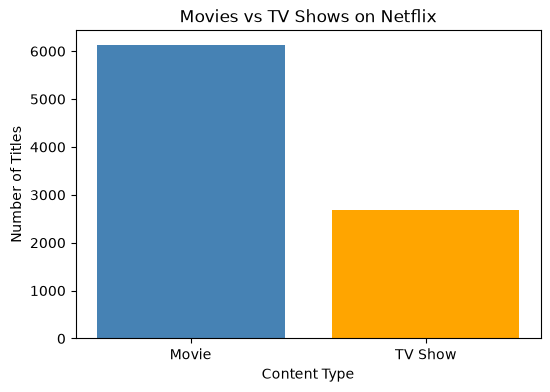

In [14]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(type_counts.index, type_counts.values, color = ["steelblue", "orange"])

plt.title("Movies vs TV Shows on Netflix")

plt.xlabel("Content Type")

plt.ylabel("Number of Titles")

plt.savefig("../images/movies_vs_tvshows.png",dpi=300, bbox_inches="tight")

plt.show()

### Business Insight

Movies dominate Netflix's catalog, with more than twice the number of TV Shows.

## 2. Top 10 Countries Producing Netflix Content

Identify the countries contributing the highest number of Netflix titles.

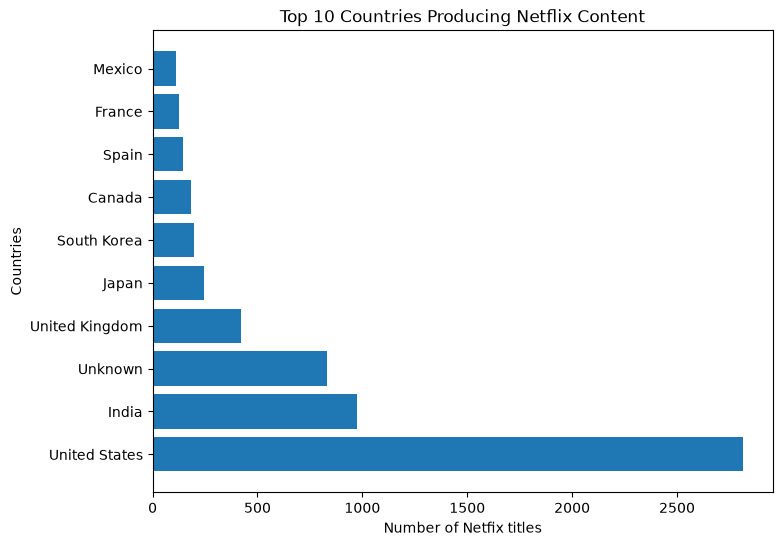

In [15]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(8,6))

plt.barh(top_countries.index, top_countries.values)

plt.title("Top 10 Countries Producing Netflix Content")

plt.xlabel("Number of Netfix titles")

plt.ylabel("Countries")

plt.savefig("../images/top10_countries.png", dpi=300, bbox_inches="tight")

plt.show()

### Business Insight

The United States contributes the highest number of Netflix titles, followed by India, showing Netflix's strong presence in these markets.

## 3. Netflix Content Released Over the Years

Analyze how Netflix's content production has changed over time.

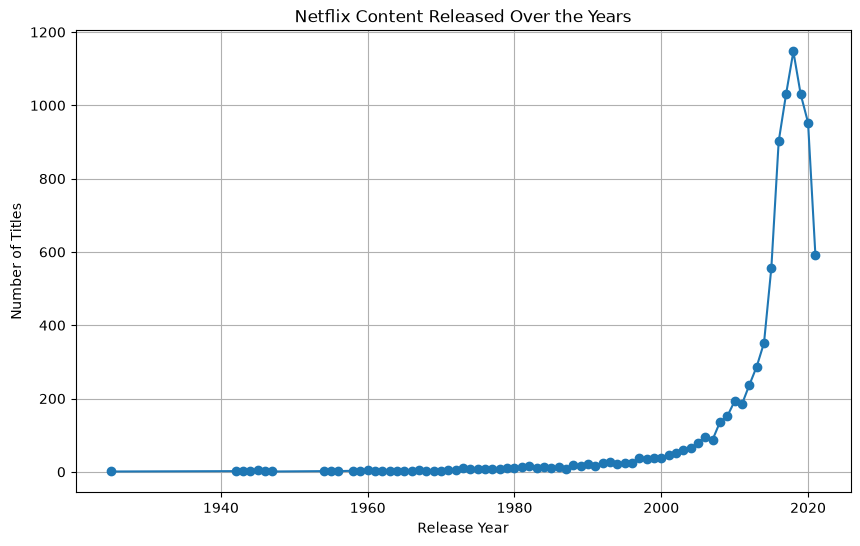

In [16]:
release_year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(10,6))

plt.plot(release_year_counts.index,
         release_year_counts.values,
         marker="o")

plt.title("Netflix Content Released Over the Years")

plt.xlabel("Release Year")

plt.ylabel("Number of Titles")

plt.grid(True)

plt.savefig("../images/release_year_trend.png", dpi=300, bbox_inches="tight")

plt.show()

### Business Insight

Netflix content production remained relatively low before 2010. After 2010, production increased rapidly and peaked around 2020, reflecting Netflix's rapid global expansion and investment in original content.

## 4. Ratings Distribution

Analyze the age ratings of Netflix content to understand its target audience.

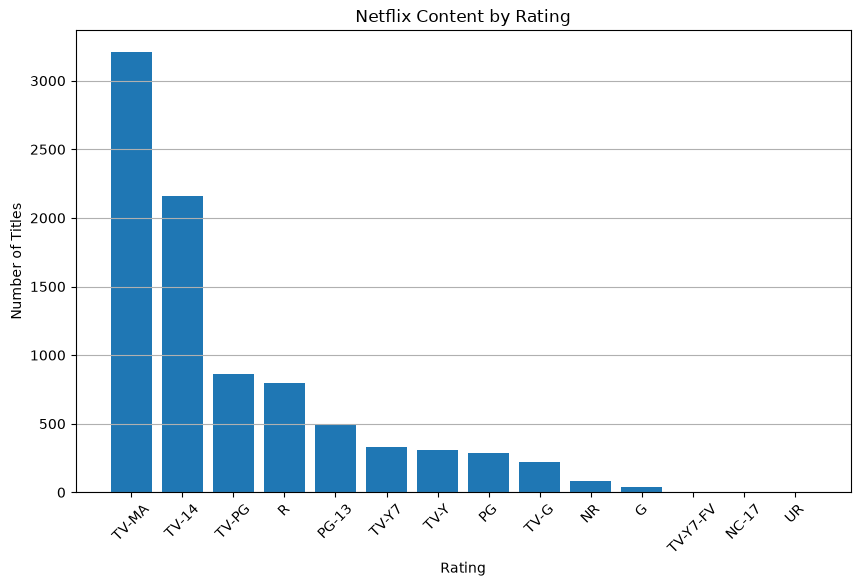

In [17]:
rating_counts = df["rating"].value_counts()

plt.figure(figsize=(10,6))

plt.bar(rating_counts.index, rating_counts.values)

plt.title("Netflix Content by Rating")

plt.xlabel("Rating")

plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.savefig("../images/ratings_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Business Insight

TV-MA and TV-14 are the most common ratings, indicating that Netflix primarily targets teenagers and adult audiences.

## 5. Top 10 Genres

Identify the most popular genres available on Netflix.

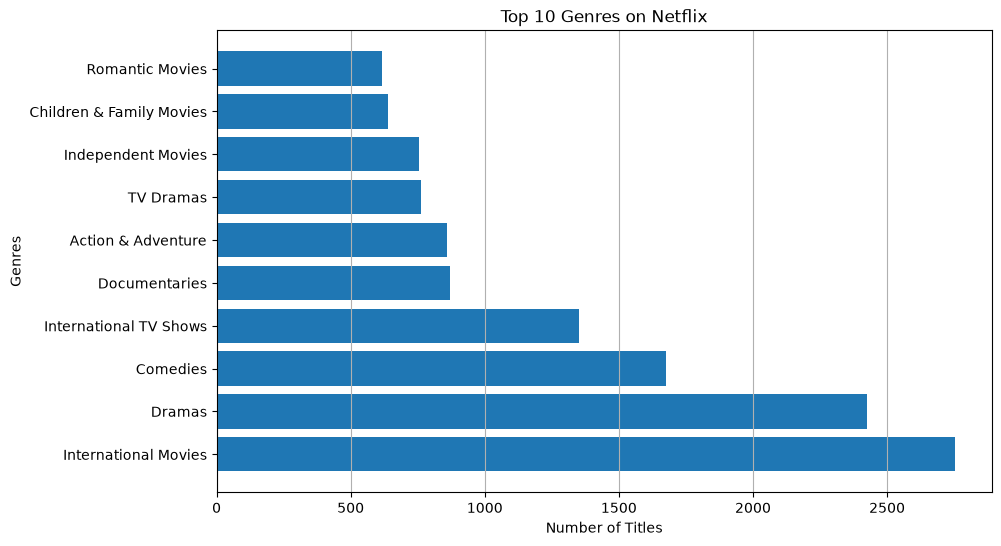

In [18]:
genres = df["listed_in"].str.split(", ")

genres = genres.explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))

plt.barh(top_genres.index, top_genres.values)

plt.title("Top 10 Genres on Netflix")

plt.xlabel("Number of Titles")

plt.ylabel("Genres")

plt.grid(axis="x")

plt.savefig("../images/top_genres.png", dpi=300, bbox_inches="tight")

plt.show()

### Business Insight

International Movies is the most common genre, followed by Dramas and Comedies, highlighting Netflix's focus on diverse global content.

# Conclusion

This exploratory data analysis revealed several important trends in Netflix's content library:

- Movies outnumber TV Shows.
- The United States and India produce the most Netflix content.
- Netflix content production increased rapidly after 2010.
- TV-MA and TV-14 dominate the catalog, indicating a focus on mature audiences.
- International Movies are Netflix's most common genre, demonstrating its global content strategy.

# Thank You

This project demonstrates the complete workflow of an Exploratory Data Analysis (EDA) project using Python, Pandas, and Matplotlib.

The insights generated can help understand Netflix's content distribution and identify trends across countries, release years, ratings, and genres.